# EDA & Classification on Cardio Dataset

This notebook predicts the presence of cardiovascular disease (`cardio`, a binary target: 0 = no disease, 1 = disease). Since the target is categorical rather than continuous, we use a **classification** model instead of linear regression, and we scale the data carefully (fit the scaler on the training set only, then apply it to the test set) to avoid data leakage.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression


## Load the Data

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")

## Dataset Information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


## Shape, Columns, and Sample

In [4]:
df.shape

(70000, 13)

In [5]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [6]:
df.sample(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
53085,75730,19944,1,160,96.0,140,80,3,2,0,0,1,1
45478,64972,14422,1,158,89.0,110,70,1,1,0,0,1,0
8698,12411,16820,1,168,69.0,120,80,1,1,0,0,1,0
66071,94327,19090,1,164,78.0,130,85,1,1,0,0,1,0
63436,90579,20257,2,173,81.0,150,100,3,3,0,1,1,1


## Summary Statistics

In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## Missing Values and Duplicates

Checking for missing values and exact duplicate rows before doing anything else.

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Number of duplicate rows: 0


## Converting Age from Days to Years

The raw `age` column is stored in days, which isn't very interpretable. We convert it to years before doing any further analysis or modelling.

In [9]:
df["age"] = df["age"] / 365

## Dropping the `id` Column

`id` is just a row identifier and carries no predictive signal, so it should not be fed into the model as a feature.

In [10]:
if "id" in df.columns:
    df = df.drop(columns=["id"])

## Target Variable Distribution

In [11]:
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

## Cardio Value Counts (Bar Chart)

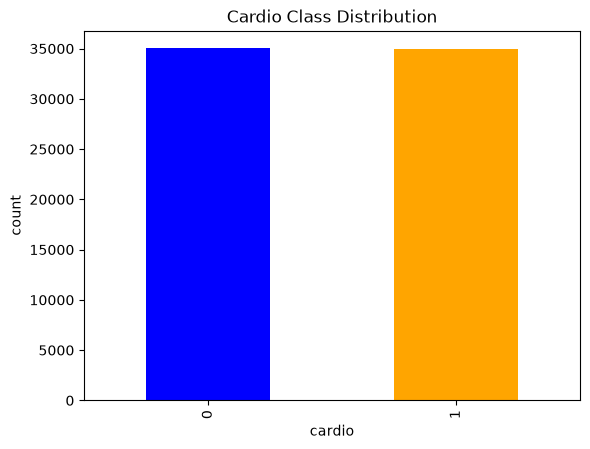

In [12]:
df["cardio"].value_counts().plot(kind="bar", color=["blue", "orange"])
plt.title("Cardio Class Distribution")
plt.xlabel("cardio")
plt.ylabel("count")
plt.show()

## Age vs Cardio (Boxplot)

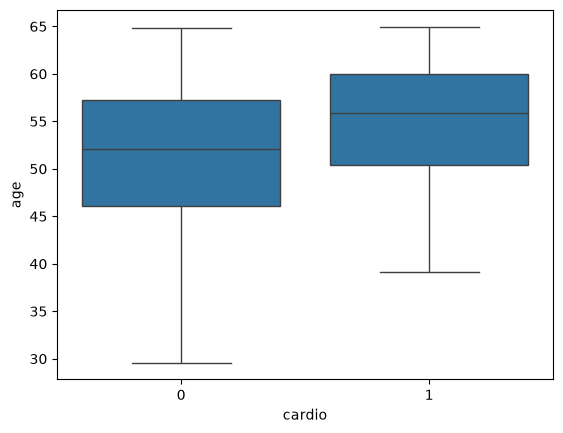

In [13]:
sns.boxplot(x="cardio", y="age", data=df)
plt.show()

## Height vs Cardio (Boxplot)

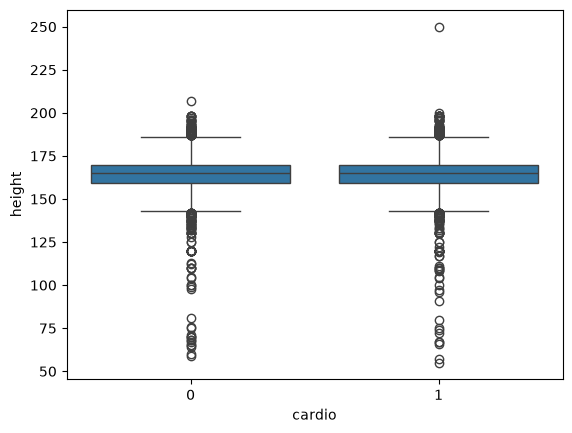

In [14]:
sns.boxplot(x="cardio", y="height", data=df)
plt.show()

## Distribution of Age (Histogram)

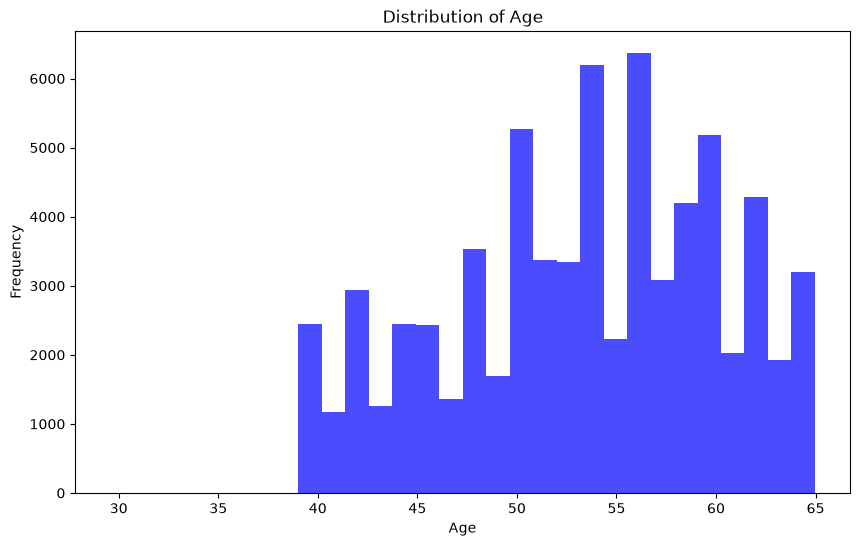

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df["age"], bins=30, color="blue", alpha=0.7)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Sorting Values by Age

In [16]:
df.sort_values(by="age", ascending=False).head(10)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
57191,64.967123,2,175,75.0,120,80,1,1,0,0,1,1
68005,64.934247,1,178,75.0,120,80,1,1,0,0,1,1
50714,64.909589,2,167,68.0,120,80,2,2,0,0,0,1
20931,64.904110,1,165,63.0,150,90,2,1,0,0,1,1
36603,64.895890,2,163,55.0,120,80,3,1,1,0,1,1
37677,64.887671,2,165,64.0,120,80,1,1,0,0,1,1
40099,64.871233,1,165,74.0,120,80,1,1,0,0,1,0
69142,64.868493,1,169,70.0,120,80,3,3,0,0,1,1
57853,64.863014,1,165,65.0,130,80,1,1,0,0,1,1
18062,64.863014,1,140,48.0,170,100,2,1,0,0,1,1


## Splitting Dataset into Features and Target Variable

We split the data into train/test **before** scaling. This matters: if we fit a scaler on the full dataset first, statistics from the test set (mean, std, min, max) leak into the training process, which gives an overly optimistic estimate of how well the model will generalize. The correct order is always: split → fit scaler on train → transform train and test.

In [17]:
x_cardio = df.drop("cardio", axis=1)
y_cardio = df["cardio"]

x_train, x_test, y_train, y_test = train_test_split(
    x_cardio, y_cardio, test_size=0.2, random_state=42, stratify=y_cardio
)

print("Train shape:", x_train.shape, " Test shape:", x_test.shape)

Train shape: (56000, 11)  Test shape: (14000, 11)


## Inspecting the Split

In [18]:
print("x_train (features for training), 4 rows:")
print(x_train.head(4))

x_train (features for training), 4 rows:
             age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
58394  52.041096       2     162    83.0    120     80            1     1   
60371  47.449315       1     158    64.0    120     80            1     1   
41399  52.101370       1     165    95.0    160    100            2     1   
11468  55.857534       1     164    83.0    150    100            1     1   

       smoke  alco  active  
58394      0     0       0  
60371      0     0       1  
41399      0     0       1  
11468      0     0       1  


In [19]:
print("y_train (labels for training), 4 rows:")
print(y_train.head(4))

y_train (labels for training), 4 rows:
58394    1
60371    0
41399    1
11468    1
Name: cardio, dtype: int64


In [20]:
print("x_test (features for testing), 2 rows:")
print(x_test.head(2))

x_test (features for testing), 2 rows:
             age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
18682  53.112329       1     155    59.5    120     85            1     1   
40992  57.756164       1     160    59.0    130     90            1     1   

       smoke  alco  active  
18682      0     0       1  
40992      0     0       1  


In [21]:
print("y_test (labels for testing), 2 rows:")
print(y_test.head(2))

y_test (labels for testing), 2 rows:
18682    0
40992    0
Name: cardio, dtype: int64


## Data Scaling (Detailed)



In [22]:
standard_scale_cols = ["age"]
minmax_scale_cols = ["height", "weight", "ap_hi", "ap_lo"]
passthrough_cols = [
    c for c in x_train.columns
    if c not in standard_scale_cols + minmax_scale_cols
]

print("StandardScaler columns:", standard_scale_cols)
print("MinMaxScaler columns:  ", minmax_scale_cols)
print("Passthrough columns:   ", passthrough_cols)

StandardScaler columns: ['age']
MinMaxScaler columns:   ['height', 'weight', 'ap_hi', 'ap_lo']
Passthrough columns:    ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


### Fitting the scalers on the training set only

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("standard", StandardScaler(), standard_scale_cols),
        ("minmax", MinMaxScaler(), minmax_scale_cols),
    ],
    remainder="passthrough",  
)

x_train_scaled_arr = preprocessor.fit_transform(x_train)
x_test_scaled_arr = preprocessor.transform(x_test)

scaled_columns = standard_scale_cols + minmax_scale_cols + passthrough_cols
x_train_scaled = pd.DataFrame(x_train_scaled_arr, columns=scaled_columns, index=x_train.index)
x_test_scaled = pd.DataFrame(x_test_scaled_arr, columns=scaled_columns, index=x_test.index)

x_train_scaled.head()

,age,height,weight,ap_hi,ap_lo,gender,cholesterol,gluc,smoke,alco,active
58394,-0.191583,0.544041,0.380952,0.016698,0.013550,2.0,1.0,1.0,0.0,0.0,0.0
60371,-0.872394,0.523316,0.280423,0.016698,0.013550,1.0,1.0,1.0,0.0,0.0,1.0
41399,-0.182647,0.559585,0.444444,0.019171,0.015357,1.0,2.0,1.0,0.0,0.0,1.0
11468,0.374269,0.554404,0.380952,0.018553,0.015357,1.0,1.0,1.0,0.0,0.0,1.0
20650,-0.499898,0.512953,0.216931,0.015461,0.012376,1.0,1.0,1.0,0.0,0.0,0.0


### Before vs After Scaling (sanity check)

Comparing summary statistics before and after scaling confirms the transform worked as expected: `age` should now have ~mean 0 / std 1, and `height`/`weight`/`ap_hi`/`ap_lo` should fall within [0, 1] (based on the training set's own min/max).

In [24]:
print("Before scaling (train):")
print(x_train[standard_scale_cols + minmax_scale_cols].describe().loc[["mean", "std", "min", "max"]])

print("\nAfter scaling (train):")
print(x_train_scaled[standard_scale_cols + minmax_scale_cols].describe().loc[["mean", "std", "min", "max"]])

Before scaling (train):
            age      height      weight         ap_hi         ap_lo
mean  53.333245  164.344089   74.222059    129.041732     96.798196
std    6.744639    8.226979   14.389746    161.551930    193.567517
min   29.750685   57.000000   11.000000   -150.000000    -70.000000
max   64.909589  250.000000  200.000000  16020.000000  11000.000000

After scaling (train):
               age    height    weight     ap_hi     ap_lo
mean  1.195742e-15  0.556187  0.334508  0.017257  0.015068
std   1.000009e+00  0.042627  0.076136  0.009991  0.017486
min  -3.496521e+00  0.000000  0.000000  0.000000  0.000000
max   1.716392e+00  1.000000  1.000000  1.000000  1.000000


## Classification Model

`cardio` is a binary label (0/1), so this is a classification problem, not a regression problem. We use **Logistic Regression**, a standard baseline classifier for binary targets, trained on the scaled features.

In [25]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Making Predictions

In [26]:
y_pred = model.predict(x_test_scaled)
y_proba = model.predict_proba(x_test_scaled)[:, 1] 

## Actual vs Predicted Class (first 30 test samples)

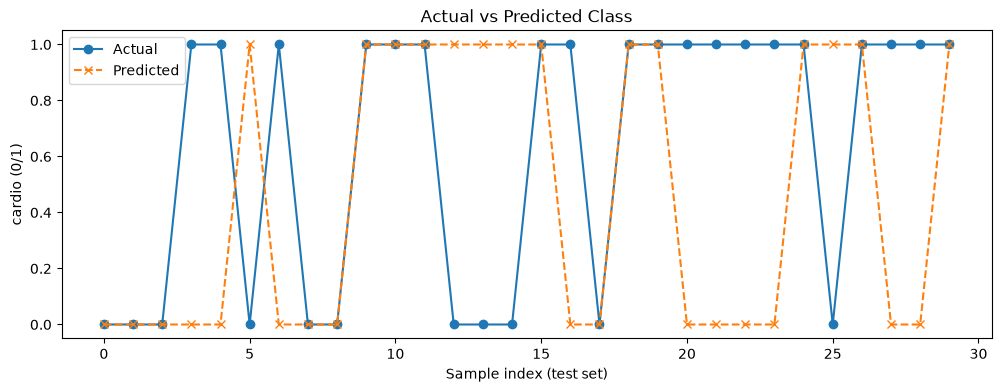

In [27]:
plt.figure(figsize=(12, 4))
sample = 30
idx = np.arange(sample)
plt.plot(idx, y_test.values[:sample], "o-", label="Actual")
plt.plot(idx, y_pred[:sample], "x--", label="Predicted")
plt.xlabel("Sample index (test set)")
plt.ylabel("cardio (0/1)")
plt.title("Actual vs Predicted Class")
plt.legend()
plt.show()